# Классификация опоздания

Бизнес-задача: понять, опоздает ли доставка, чтобы решить, стоит ли предлагать компенсацию при опоздании. Если мы не уверены в том, что доставка приедет вовремя, то и ответственность за опоздание брать не будем

Задача ML: предсказать факт опоздания доставки (бинарная классификация)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

## Загрузка и выбор признаков

Модель должна делать прогноз в момент оформления заказа. Поэтому надо будет исключать

- оба таргета: is_delayed, total_freight
- идентификаторы
- сведения, появляющиеся после заказа или после доставки
- признаки, напрямую использующие целевые переменные
- технические даты
- константный order_status


order_purchase_timestamp сохраняется только для сортировки и временного разбиения

In [2]:
df = pd.read_csv('data/olist_enriched_clean.csv', parse_dates=['order_purchase_timestamp', 'order_estimated_delivery_date'])
df = df.sort_values('order_purchase_timestamp').reset_index(drop=True)

num_features = [
    'n_items',
    'total_price',
    'avg_price',
    'payment_installments',
    'customer_lat',
    'customer_lng',
    'seller_lat',
    'seller_lng',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_photos_qty',
    'order_weekday',
    'order_month',
    'order_year',
    'order_hour',
    'product_volume_cm3',
    'distance_km',
    'customer_population',
    'customer_gdp_per_capita',
    'customer_hdi',
    'customer_urban_pct',
    'customer_population_density',
    'seller_gdp_per_capita',
    'seller_hdi',
    'seller_urban_pct',
    'hdi_diff',
    'purchase_precipitation_mm',
    'purchase_temp_avg_c',
    'purchase_heavy_rain',
    'purchase_is_holiday',
    'days_to_next_holiday',
    'estimated_delivery_days',
]

cat_features = [
    'payment_type',
    'customer_state',
    'seller_state',
    'product_category_name_english',
    'customer_region',
    'seller_region',
]

candidate_features = num_features + cat_features

X = df[candidate_features].copy()
y = df['is_delayed'].astype(int).copy()
order_dates = df['order_purchase_timestamp'].copy()

print(f'Наблюдений: {len(df):}')
print(f'Признаков: {len(candidate_features)}')
print(f'Доля опозданий: {y.mean():.2%}')

Наблюдений: 96203
Признаков: 40
Доля опозданий: 8.13%


## Временное train/test-разбиение 70/30

In [3]:
split_index = int(len(df) * 0.70)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

train_dates = order_dates.iloc[:split_index]
test_dates = order_dates.iloc[split_index:]

pd.DataFrame({
    'sample': ['train', 'test'],
    'rows': [len(X_train), len(X_test)],
    'date_start': [train_dates.min(), test_dates.min()],
    'date_end': [train_dates.max(), test_dates.max()],
    'delayed_n': [int(y_train.sum()), int(y_test.sum())],
    'delayed_rate': [y_train.mean(), y_test.mean()],
})

,sample,rows,date_start,date_end,delayed_n,delayed_rate
0,train,67342,2017-01-05 11:56:06,2018-04-16 01:48:45,6093,0.090478
1,test,28861,2018-04-16 02:05:10,2018-08-29 15:00:37,1729,0.059908


Доля опозданий во времени меняется, поэтому случайный сплит дал бы слишком оптимистичную оценку. Внутри train используется TimeSeriesSplit.
Финальный test не участвует в выборе гиперпараметров.

In [4]:
cv = TimeSeriesSplit(n_splits=3)

cv_rows = []
for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train), start=1):
    cv_rows.append({
        'fold': fold,
        'train_rows': len(train_idx),
        'valid_rows': len(valid_idx),
        'train_end': train_dates.iloc[train_idx[-1]],
        'valid_start': train_dates.iloc[valid_idx[0]],
        'valid_end': train_dates.iloc[valid_idx[-1]],
        'train_delay_rate': y_train.iloc[train_idx].mean(),
        'valid_delay_rate': y_train.iloc[valid_idx].mean(),
    })

pd.DataFrame(cv_rows)

,fold,train_rows,valid_rows,train_end,valid_start,valid_end,train_delay_rate,valid_delay_rate
0,1,16837,16835,2017-07-24 16:16:18,2017-07-24 16:19:27,2017-11-20 11:00:48,0.044485,0.050371
1,2,33672,16835,2017-11-20 11:00:48,2017-11-20 11:00:54,2018-02-01 08:06:41,0.047428,0.103713
2,3,50507,16835,2018-02-01 08:06:41,2018-02-01 08:10:40,2018-04-16 01:48:45,0.066189,0.163350


## Типы признаков

In [5]:
categorical_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numeric_features = [column for column in X_train.columns if column not in categorical_features]

pd.DataFrame({
    'type': ['numeric', 'categorical'],
    'count': [len(numeric_features), len(categorical_features)],
    'features': [numeric_features, categorical_features],
})

,type,count,features
0,numeric,34,"[n_items, total_price, avg_price, payment_inst..."
1,categorical,6,"[payment_type, customer_state, seller_state, p..."


In [6]:
cardinality = (
    X_train[categorical_features]
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .rename('n_unique')
    .to_frame()
)

cardinality

,n_unique
product_category_name_english,72
customer_state,27
seller_state,22
customer_region,5
seller_region,5
payment_type,4


In [7]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67342 entries, 0 to 67341
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   n_items                        67342 non-null  int64  
 1   total_price                    67342 non-null  float64
 2   avg_price                      67342 non-null  float64
 3   payment_installments           67342 non-null  float64
 4   customer_lat                   67161 non-null  float64
 5   customer_lng                   67161 non-null  float64
 6   seller_lat                     67177 non-null  float64
 7   seller_lng                     67177 non-null  float64
 8   product_weight_g               67326 non-null  float64
 9   product_length_cm              67326 non-null  float64
 10  product_height_cm              67326 non-null  float64
 11  product_width_cm               67326 non-null  float64
 12  product_photos_qty             66124 non-null 

In [8]:
numeric_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')

X_train_numeric = numeric_imputer.fit_transform(X_train[numeric_features])
X_test_numeric = numeric_imputer.transform(X_test[numeric_features])

X_train_categorical = categorical_imputer.fit_transform(X_train[categorical_features])
X_test_categorical = categorical_imputer.transform(X_test[categorical_features])

print('Числовые train:', X_train_numeric.shape)
print('Категориальные train:', X_train_categorical.shape)

Числовые train: (67342, 34)
Категориальные train: (67342, 6)


In [9]:
scaler = StandardScaler()

X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

In [ ]:
onehot_encoder = OneHotEncoder(handle_unknown='ignore', min_frequency=10, sparse_output=False)

X_train_categorical_encoded = onehot_encoder.fit_transform(X_train_categorical)
X_test_categorical_encoded = onehot_encoder.transform(X_test_categorical)

print(f'Категориальные признаки до OHE {len(categorical_features)} и после {X_train_categorical_encoded.shape[1]}')

Категориальные признаки до OHE 6 и после 129


In [11]:
X_train_transformed = np.hstack([X_train_numeric_scaled, X_train_categorical_encoded])
X_test_transformed = np.hstack([X_test_numeric_scaled, X_test_categorical_encoded])

print('Исходный train:', X_train.shape)
print('Преобразованный train:', X_train_transformed.shape)

Исходный train: (67342, 40)
Преобразованный train: (67342, 163)


## Baseline

In [ ]:
dummy = DummyClassifier(strategy='prior')
dummy.fit(X_train_transformed, y_train)
dummy_probability = dummy.predict_proba(X_test_transformed)[:, 1]

print('Dummy ROC-AUC:', roc_auc_score(y_test, dummy_probability))
print('Dummy PR-AUC:', average_precision_score(y_test, dummy_probability))

Dummy ROC-AUC: 0.5
Dummy PR-AUC: 0.059907834101382486


## PCA и KNN

KNN используется с РСА именно потому что для KNN желательно уменьшить количество признаков, по которым будут определяться соседи

In [13]:
pca = PCA(
      n_components=0.95, # 95% сохраненной дисперсии как наиболее логичный
      svd_solver='full', # написано что рандом и авто не работаю с такой дисперсией. Ну и датасет не то, чтобы большой у нас - поэтому фулл
      )

X_train_pca = pca.fit_transform(X_train_transformed)
X_test_pca = pca.transform(X_test_transformed)

print('Признаков до PCA:', X_train_transformed.shape[1])
print('Компонент после PCA:', pca.n_components_)
print('Сохранённая дисперсия:', pca.explained_variance_ratio_.sum(),)

Признаков до PCA: 163
Компонент после PCA: 29
Сохранённая дисперсия: 0.9522914919215594


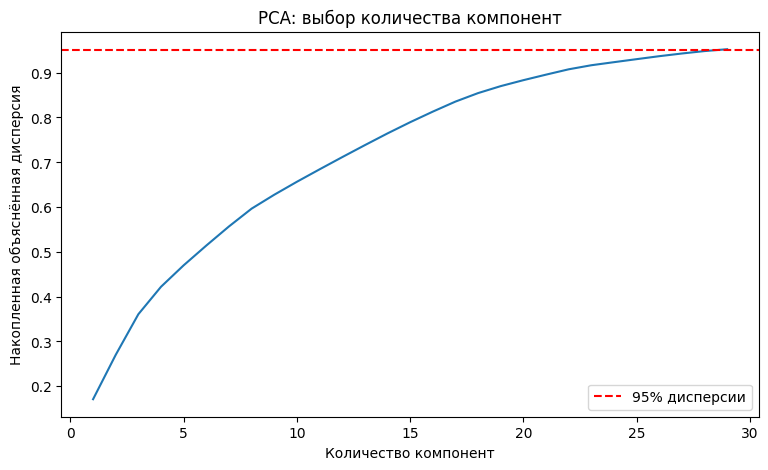

In [14]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,)
plt.axhline(0.95, color='red', linestyle='--', label='95% дисперсии')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('PCA: выбор количества компонент')
plt.legend()

plt.show()

Если посмотреть РСА, видно, что когда объясненная дисперсия достигает около 95%, то она выходит в насыщение (по сути, по правилу локтя); 
Менять от 95% особо смысла нет - уменьшение признаков будет быстро ронять дисперсию, а увеличение будет слишком медленно ее увеличивать - 95%, выбранные сначала на здравый смысл оптимальны 

In [15]:
knn_cv = TimeSeriesSplit(n_splits=3)

knn_model = KNeighborsClassifier(n_jobs=1,)

knn_param_grid = {
      'n_neighbors': [10, 15, 20, 30, 50, 100],
      'weights': ['distance'], #['uniform', 'distance'], # будет ли вес соседа зависеть от расстояния
      'p': [2] #[1, 2], # манхеттен и евклидово - это типо степени по Маньковскому просто
}

In [16]:
knn_grid_search = GridSearchCV(
      estimator=knn_model,
      param_grid=knn_param_grid,
      scoring={
          'recall': 'recall',
          'average_precision': 'average_precision',
      },
      refit='recall',
      cv=knn_cv,
      n_jobs=1,
      return_train_score=True,
      verbose=2,
)

In [17]:
knn_grid_search.fit(X_train_pca, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ..............n_neighbors=10, p=2, weights=distance; total time=   0.4s
[CV] END ..............n_neighbors=10, p=2, weights=distance; total time=   0.3s
[CV] END ..............n_neighbors=10, p=2, weights=distance; total time=   0.5s
[CV] END ..............n_neighbors=15, p=2, weights=distance; total time=   0.2s
[CV] END ..............n_neighbors=15, p=2, weights=distance; total time=   0.3s
[CV] END ..............n_neighbors=15, p=2, weights=distance; total time=   0.5s
[CV] END ..............n_neighbors=20, p=2, weights=distance; total time=   0.2s
[CV] END ..............n_neighbors=20, p=2, weights=distance; total time=   0.3s
[CV] END ..............n_neighbors=20, p=2, weights=distance; total time=   0.5s
[CV] END ..............n_neighbors=30, p=2, weights=distance; total time=   0.2s
[CV] END ..............n_neighbors=30, p=2, weights=distance; total time=   0.4s
[CV] END ..............n_neighbors=30, p=2, weigh

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=KNeighborsClassifier(n_jobs=1), n_jobs=1,
             param_grid={'n_neighbors': [10, 15, 20, 30, 50, 100], 'p': [2],
                         'weights': ['distance']},
             refit='recall', return_train_score=True,
             scoring={'average_precision': 'average_precision',
                      'recall': 'recall'},
             verbose=2)

In [18]:
best_knn_model = knn_grid_search.best_estimator_
knn_test_probability = best_knn_model.predict_proba(X_test_pca)[:, 1]

In [19]:
for threshold in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]:
    predictions = (knn_test_probability >= threshold)
    print(f'Доля предсказанных опозданий для {threshold}: {predictions.mean()}')

Доля предсказанных опозданий для 0.1: 0.36048646963029696
Доля предсказанных опозданий для 0.15: 0.2761165586778005
Доля предсказанных опозданий для 0.2: 0.19729046117598142
Доля предсказанных опозданий для 0.25: 0.1448321263989467
Доля предсказанных опозданий для 0.3: 0.10505526489033644
Доля предсказанных опозданий для 0.35: 0.07227746786320641
Доля предсказанных опозданий для 0.4: 0.0506565954055646


In [20]:
print('Истинное количество опозданий в test:', y_test.sum()/y_test.count())

Истинное количество опозданий в test: 0.059907834101382486


In [21]:
knn_test_prediction = (knn_test_probability >= 0.3)

print('Доля предсказанных опозданий:', knn_test_prediction.mean())

Доля предсказанных опозданий: 0.10505526489033644


In [22]:
knn_confusion_matrix = confusion_matrix(y_test, knn_test_prediction, labels=[0, 1])

pd.DataFrame(knn_confusion_matrix,
      index=['Факт: вовремя', 'Факт: опоздание'],
      columns=['Прогноз: вовремя', 'Прогноз: опоздание'],
  )

,Прогноз: вовремя,Прогноз: опоздание
Факт: вовремя,24379,2753
Факт: опоздание,1450,279


In [23]:
knn_test_prediction = (knn_test_probability >= 0.05)

print('Доля предсказанных опозданий:', knn_test_prediction.mean())

knn_confusion_matrix = confusion_matrix(y_test, knn_test_prediction, labels=[0, 1])

pd.DataFrame(
      knn_confusion_matrix,
      index=['Факт: вовремя', 'Факт: опоздание'],
      columns=['Прогноз: вовремя', 'Прогноз: опоздание'],
  )

Доля предсказанных опозданий: 0.5297806728803576


,Прогноз: вовремя,Прогноз: опоздание
Факт: вовремя,12792,14340
Факт: опоздание,779,950


Вообще, с понижением трешхолда до 5% у нас очень сильно возросло количество ложных положительных классов, а при этом реколл на уровне 0.5. Это очень плохая точность для наших бизнес-целей. Кажется, KNN просто не подходит для них из-за сильного дисбаланса классов - вокруг точек слишком много соседей без опоздания

Именно поэтому идем в более сложные модели

## Сложные модельки, на которые есть надежда

Главная метрика - recall, потому что в этой задаче важнее находить как можно больше заказов с риском опоздания.
При этом отдельно смотрим precision, F1, PR-AUC и долю положительных прогнозов. Это нужно, чтобы не выбрать модель, которая получает высокий recall только потому, что почти всем заказам ставит риск опоздания.

In [24]:
recall_scoring = {
    'recall': 'recall',
    'pr_auc': 'average_precision',
}

RECALL_MODEL_THRESHOLD = 0.3 # подобрано от 0.5 просто ручками - тк 0.5 это достаточно лояльный порог, а нам важно не пропустить наблюдения положительного класса 
# еще там дальше есть график по трешхолдам

def classification_metrics(model_name, probabilities, threshold=RECALL_MODEL_THRESHOLD):
    predictions = (probabilities >= threshold)
    return {
        'model': model_name,
        'threshold': threshold,
        'ROC-AUC': roc_auc_score(y_test, probabilities),
        'PR-AUC': average_precision_score(y_test, probabilities),
        'precision': precision_score(y_test, predictions),
        'recall': recall_score(y_test, predictions),
        'F1': f1_score(y_test, predictions),
        'predicted_positive_rate': predictions.mean(),
}


def threshold_report(model_name, probabilities, thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.05, 0.7, 0.05), 2)

    rows = [classification_metrics(model_name, probabilities, threshold=float(threshold)) for threshold in thresholds]
    return pd.DataFrame(rows)

knn_recall_metrics = classification_metrics('KNN + PCA', knn_test_probability, threshold=0.05)

print(f'Порог для финального сравнения моделей: {RECALL_MODEL_THRESHOLD}')
pd.DataFrame([knn_recall_metrics]).set_index('model')

Порог для финального сравнения моделей: 0.3


,threshold,ROC-AUC,PR-AUC,precision,recall,F1,predicted_positive_rate
model,,,,,,,
KNN + PCA,0.05,0.536727,0.074353,0.062132,0.549451,0.11164,0.529781


### Logistic Regression

In [ ]:
numeric_logistic = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_logistic = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=10)),
])

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_logistic, numeric_features),
        ('categorical', categorical_logistic, categorical_features),
    ],
    remainder='drop',
)

logistic_pipeline = Pipeline([
    ('preprocessor', logistic_preprocessor),
    (
        'model',
        LogisticRegression(
            solver='liblinear',
            max_iter=1000,
            random_state=67,
        ),
    ),
])

logistic_grid = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__penalty': ['l1', 'l2'], 
    'model__class_weight': [None, 'balanced'],
}

logistic_recall_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_grid,
    scoring=recall_scoring,
    refit='recall',
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    verbose=1,
)

logistic_recall_search.fit(X_train, y_train)
logistic_recall_probability = logistic_recall_search.best_estimator_.predict_proba(X_test)[:, 1]
logistic_recall_metrics = classification_metrics('Logistic Regression', logistic_recall_probability)

pd.DataFrame([logistic_recall_metrics]).set_index('model')

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,threshold,ROC-AUC,PR-AUC,precision,recall,F1,predicted_positive_rate
model,,,,,,,
Logistic Regression,0.3,0.701201,0.114703,0.064013,0.998843,0.120315,0.934791


In [26]:
logistic_cv = pd.DataFrame(logistic_recall_search.cv_results_)
logistic_columns = [
    'param_model__C',
    'param_model__penalty',
    'param_model__class_weight',
    'mean_train_recall',
    'mean_test_recall',
    'std_test_recall',
    'mean_test_pr_auc',
    'rank_test_recall',
]

logistic_cv[logistic_columns].sort_values('rank_test_recall').reset_index(drop=True)

,param_model__C,param_model__penalty,param_model__class_weight,mean_train_recall,mean_test_recall,std_test_recall,mean_test_pr_auc,rank_test_recall
0,0.01,l1,balanced,0.653566,0.544204,0.169901,0.197266,1
1,0.01,l2,balanced,0.662469,0.517374,0.199753,0.190281,2
2,0.10,l2,balanced,0.670438,0.496768,0.222636,0.176127,3
3,1.00,l2,balanced,0.673341,0.486958,0.230712,0.170967,4
4,1.00,l1,balanced,0.672217,0.486698,0.230599,0.171063,5
5,10.00,l2,balanced,0.674512,0.484629,0.233170,0.169433,6
6,10.00,l1,balanced,0.675129,0.484578,0.233077,0.169502,7
7,0.10,l1,balanced,0.666689,0.484385,0.203414,0.188756,8
8,10.00,l1,None,0.002342,0.004626,0.004431,0.178276,9
9,10.00,l2,None,0.002451,0.004626,0.004431,0.178020,9


### Histogram Gradient Boosting

Для бустинга оставляем отдельный preprocessing: числовые признаки только заполняются, категориальные кодируются через `OrdinalEncoder`, потому что деревьям не нужно масштабирование и one-hot.

In [ ]:
numeric_boosting = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_boosting = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    (
        'ordinal',#деревьям не нужен one-hot OHE сильно раздувает размерность ordinal encoding дешевле и быстрее деревья умеют работать с “псевдопорядком” без проблем
        OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1,
            encoded_missing_value=-1,
        ),
    ),
])

boosting_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_boosting, numeric_features),
        ('categorical', categorical_boosting, categorical_features),
    ],
    remainder='drop',
)

categorical_mask = [False] * len(numeric_features) + [True] * len(categorical_features)

boosting_pipeline = Pipeline([
    ('preprocessor', boosting_preprocessor),
    (
        'model',
        HistGradientBoostingClassifier(
            categorical_features=categorical_mask,
            random_state=67,
            early_stopping=True,
            validation_fraction=0.15,
        ),
    ),
])

boosting_distributions = {
    'model__learning_rate': [0.02, 0.08, 0.15],
    'model__max_iter': [120, 200, 350],
    'model__max_leaf_nodes': [7, 25, 63],
    'model__max_depth': [None, 4, 8],
    'model__min_samples_leaf': [10, 40, 100],
    'model__l2_regularization': [0.0, 0.1, 1.0, 10.0],
    'model__class_weight': [None, 'balanced'],
}
boosting_iterations = 25

boosting_recall_search = RandomizedSearchCV(
    estimator=boosting_pipeline,
    param_distributions=boosting_distributions,
    n_iter=boosting_iterations,
    scoring=recall_scoring,
    refit='recall',
    cv=cv,
    random_state=67,
    n_jobs=1,
    return_train_score=True,
    verbose=1,
)

boosting_recall_search.fit(X_train, y_train)
boosting_recall_probability = boosting_recall_search.best_estimator_.predict_proba(X_test)[:, 1]
classification_metrics('HistGradientBoosting', boosting_recall_probability)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


{'model': 'HistGradientBoosting',
 'threshold': 0.3,
 'ROC-AUC': np.float64(0.5694715559353936),
 'PR-AUC': np.float64(0.08582170282022109),
 'precision': 0.06729216670303295,
 'recall': 0.891844997108155,
 'F1': 0.12514202239896122,
 'predicted_positive_rate': np.float64(0.7939780326392016)}

In [28]:
boosting_cv = pd.DataFrame(boosting_recall_search.cv_results_)
boosting_columns = [
    'param_model__learning_rate',
    'param_model__max_iter',
    'param_model__max_leaf_nodes',
    'param_model__max_depth',
    'param_model__min_samples_leaf',
    'param_model__l2_regularization',
    'param_model__class_weight',
    'mean_train_recall',
    'mean_test_recall',
    'std_test_recall',
    'mean_test_pr_auc',
    'rank_test_recall',
]

boosting_cv[boosting_columns].sort_values('rank_test_recall').reset_index(drop=True)

,param_model__learning_rate,param_model__max_iter,param_model__max_leaf_nodes,param_model__max_depth,param_model__min_samples_leaf,param_model__l2_regularization,param_model__class_weight,mean_train_recall,mean_test_recall,std_test_recall,mean_test_pr_auc,rank_test_recall
0,0.02,120,7,None,10,1.0,balanced,0.677174,0.605809,0.235718,0.188663,1
1,0.08,120,7,4,100,0.0,balanced,0.717556,0.597623,0.245722,0.187205,2
2,0.15,120,7,None,10,10.0,balanced,0.729495,0.581504,0.251242,0.193520,3
3,0.15,120,7,None,10,0.1,balanced,0.732397,0.579572,0.282258,0.189482,4
4,0.15,120,7,4,10,0.1,balanced,0.728053,0.569705,0.272403,0.185170,5
5,0.02,120,63,4,40,0.1,balanced,0.694877,0.566559,0.230564,0.184165,6
6,0.02,350,25,8,100,1.0,balanced,0.766877,0.553766,0.256471,0.194702,7
7,0.02,200,25,None,100,1.0,balanced,0.770267,0.552589,0.263846,0.194146,8
8,0.15,120,25,None,10,1.0,balanced,0.795363,0.535448,0.239918,0.190387,9
9,0.15,200,63,None,40,1.0,balanced,0.875245,0.425028,0.222539,0.178506,10


## Сравнение моделей на test

Основная таблица отсортирована по recall. Дополнительно смотрим predicted_positive_rate: если он слишком высокий, модель будет находить много опозданий ценой большого количества ложных тревог.

In [29]:
test_probabilities = {
    'KNN + PCA': knn_test_probability,
    'Logistic Regression': logistic_recall_probability,
    'HistGradientBoosting': boosting_recall_probability,
}

recall_model_metrics = pd.DataFrame([
    classification_metrics(name, probabilities)
    for name, probabilities in test_probabilities.items()
]).set_index('model').sort_values('recall', ascending=False)

display(recall_model_metrics.style.highlight_max(color='lightgreen'))

,threshold,ROC-AUC,PR-AUC,precision,recall,F1,predicted_positive_rate
model,,,,,,,
Logistic Regression,0.300000,0.701201,0.114703,0.064013,0.998843,0.120315,0.934791
HistGradientBoosting,0.300000,0.569472,0.085822,0.067292,0.891845,0.125142,0.793978
KNN + PCA,0.300000,0.536727,0.074353,0.092018,0.161365,0.117202,0.105055


Чет слишком много предсказаний положительного класса у логрегрессии и бустинга. Надо поглядеть по трешхолдам

In [ ]:
threshold_metrics = pd.concat([threshold_report(name, probabilities) for name, probabilities in test_probabilities.items()], ignore_index=True,)#“не сохраняй старые индексы, создай новый подряд: 0,1,2,...”
threshold_metrics_view = threshold_metrics.sort_values(['model', 'threshold']).reset_index(drop=True)

threshold_metrics_view

,model,threshold,ROC-AUC,PR-AUC,precision,recall,F1,predicted_positive_rate
0,HistGradientBoosting,0.05,0.569472,0.085822,0.059908,1.000000,0.113043,1.000000
1,HistGradientBoosting,0.10,0.569472,0.085822,0.059908,1.000000,0.113043,1.000000
2,HistGradientBoosting,0.15,0.569472,0.085822,0.059908,1.000000,0.113043,1.000000
3,HistGradientBoosting,0.20,0.569472,0.085822,0.059908,1.000000,0.113043,1.000000
4,HistGradientBoosting,0.25,0.569472,0.085822,0.060377,0.998265,0.113867,0.990506
5,HistGradientBoosting,0.30,0.569472,0.085822,0.067292,0.891845,0.125142,0.793978
6,HistGradientBoosting,0.35,0.569472,0.085822,0.068686,0.578369,0.122790,0.504452
7,HistGradientBoosting,0.40,0.569472,0.085822,0.067621,0.399075,0.115646,0.353557
8,HistGradientBoosting,0.45,0.569472,0.085822,0.069332,0.342973,0.115347,0.296351
9,HistGradientBoosting,0.50,0.569472,0.085822,0.072186,0.307114,0.116896,0.254877


Так, выделим наиболее перспективные

In [31]:
threshold_metrics_view[(threshold_metrics_view['predicted_positive_rate'] <= 0.50) & (threshold_metrics_view['recall'] >= 0.50)].sort_values(['recall'], ascending=[False])

,model,threshold,ROC-AUC,PR-AUC,precision,recall,F1,predicted_positive_rate
37,Logistic Regression,0.60,0.701201,0.114703,0.098117,0.741469,0.173302,0.452722
38,Logistic Regression,0.65,0.701201,0.114703,0.107753,0.602082,0.182792,0.334742


То есть, в ложные положительные предсказания будут составлять примерно 0.3-0.4 (с учтом что часть predicted_positive_rate истинна), что в целом не страшно (тк просто им не будет даваться гарантия быстрой доставки), а более половины пользователей будут иметь гарантии и будут больше доверять. При этом, пропустим мы не более половины действительно положительных случаев. При этом, у нас будет еще установлено ограничение по стоимости предсказанной доставки, а значит те заказы, которые мы пропустим, будут недорогими и компания много денег не потеряет

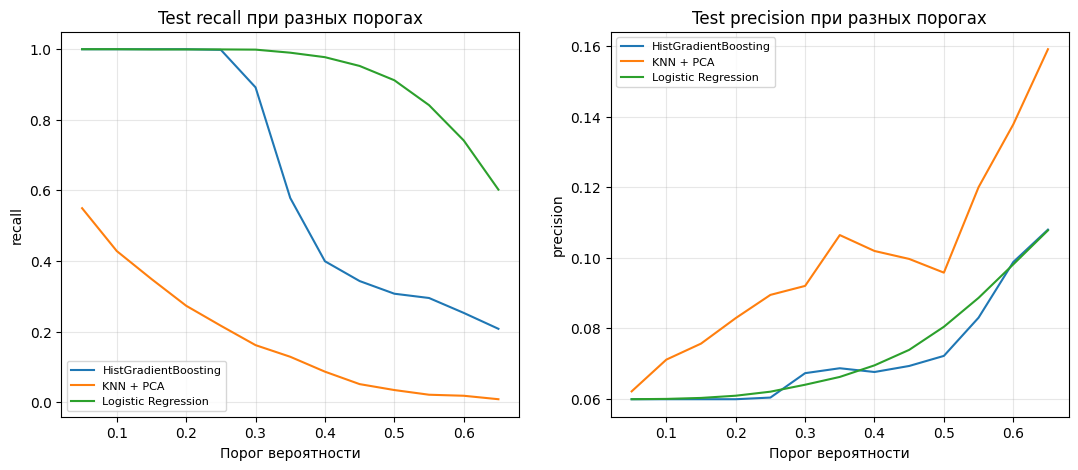

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model_name, group in threshold_metrics.groupby('model'):
    group = group.sort_values('threshold')
    axes[0].plot(group['threshold'], group['recall'], label=model_name)
    axes[1].plot(group['threshold'], group['precision'], label=model_name)

for ax, metric in zip(axes, ['recall', 'precision']):
    ax.set_xlabel('Порог вероятности')
    ax.set_ylabel(metric)
    ax.set_title(f'Test {metric} при разных порогах')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.show()

## LogReg выбранного

In [ ]:
FINAL_THRESHOLD = 0.60
best_logistic = logistic_recall_search.best_estimator_

def logistic_threshold_recall_scorer(estimator, X, y):
      probabilities = estimator.predict_proba(X)[:, 1]
      predictions = (probabilities >= FINAL_THRESHOLD)
      return recall_score(y, predictions, zero_division=0)

#если признак важный — его перемешивание сильно ухудшит качество модели
logistic_importance = permutation_importance(
      best_logistic,
      X_test,
      y_test,
      scoring=logistic_threshold_recall_scorer,
      n_repeats=5,
      random_state=67,
      n_jobs=1,
)

logistic_importance_table = (
      pd.DataFrame({
          'feature': X_test.columns,
          'importance_mean': logistic_importance.importances_mean,
          'importance_std': logistic_importance.importances_std,
      })
      .sort_values('importance_mean', ascending=False)
)

logistic_importance_table.head(15)

,feature,importance_mean,importance_std
33,estimated_delivery_days,0.011683,0.001731
18,distance_km,0.010526,0.004471
36,seller_state,0.005205,0.001508
4,customer_lat,0.001272,0.000433
26,seller_urban_pct,0.000000,0.000000
1,total_price,0.000000,0.000000
21,customer_hdi,0.000000,0.000000
22,customer_urban_pct,0.000000,0.000000
23,customer_population_density,0.000000,0.000000
24,seller_gdp_per_capita,0.000000,0.000000


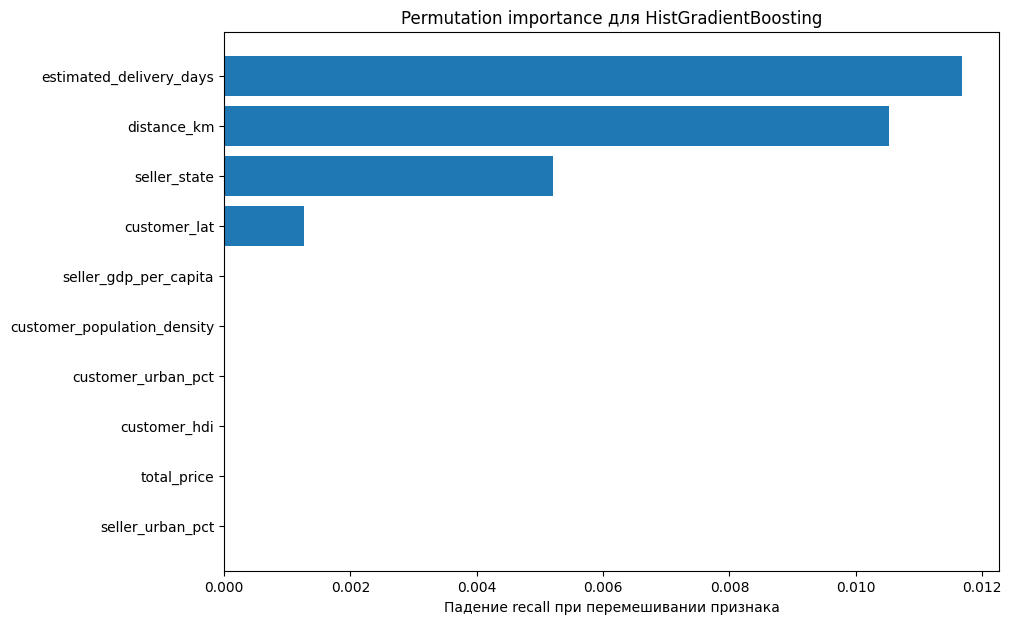

In [ ]:
plt.figure(figsize=(10, 7))
plot_data = logistic_importance_table.head(10).sort_values('importance_mean')
plt.barh(plot_data['feature'], plot_data['importance_mean'])
plt.xlabel('Падение recall при перемешивании признака')
plt.title('Permutation importance для Logistic Regression')

plt.show()